# Lab 2: Image Enhancement

In [2]:
! pip install scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 8.0 MB/s eta 0:00:0000:0100:01m


In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy import ndimage

# Path to directory with images
dataDir = 'images'

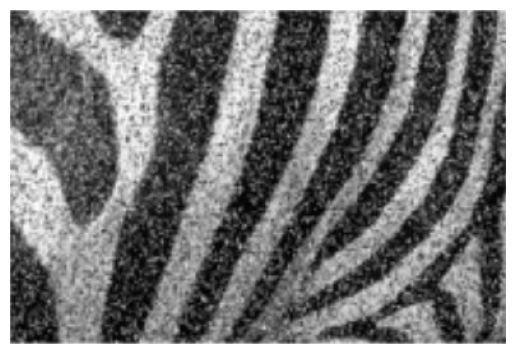

In [2]:
# Open noisy image
img = cv2.imread(os.path.join(dataDir, 'zebra_01_noisy.jpg'), cv2.IMREAD_GRAYSCALE)

# Show image
plt.imshow(img, cmap="gray", vmin=0, vmax=255)
_ = plt.axis("off")

### 1. Filtering and Smoothing

[Check tutorial here!](https://docs.opencv.org/4.x/dc/dd3/tutorial_gausian_median_blur_bilateral_filter.html)

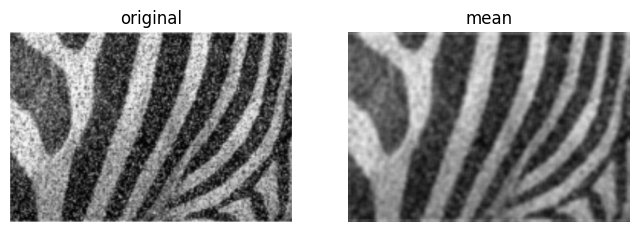

In [13]:
# Apply mean filter to the image
img_mean_filter = cv2.blur(img, ksize=(7, 7))

# Show image
f, axarr = plt.subplots(1, 2, figsize=(8, 4))
axarr[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axarr[0].set_title("original")
axarr[0].axis("off")

axarr[1].imshow(img_mean_filter, cmap="gray", vmin=0, vmax=255)
axarr[1].set_title("mean")
_ = axarr[1].axis("off")

Exercise 1.1: Apply median, Gaussian and bilateral filters to the image.

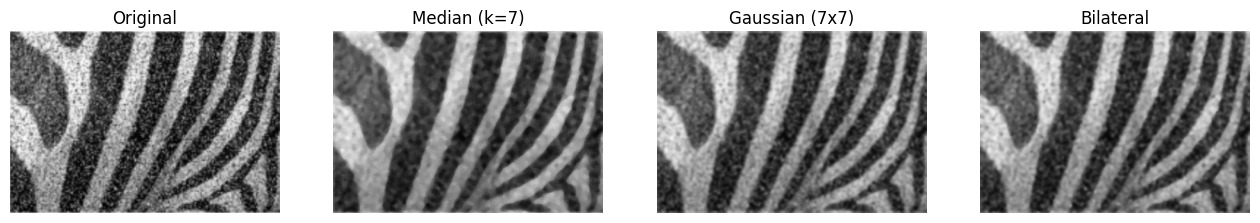

In [15]:
img_median_filter = cv2.medianBlur(img, ksize=7)

img_gaussian_filter = cv2.GaussianBlur(img, ksize=(7, 7), sigmaX=0, sigmaY=0)

img_bilateral_filter = cv2.bilateralFilter(img, d=7, sigmaColor=75, sigmaSpace=75)

f, axarr = plt.subplots(1, 4, figsize=(16, 4))

axarr[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axarr[0].set_title("Original")
axarr[0].axis("off")

axarr[1].imshow(img_median_filter, cmap="gray", vmin=0, vmax=255)
axarr[1].set_title("Median (k=7)")
axarr[1].axis("off")

axarr[2].imshow(img_gaussian_filter, cmap="gray", vmin=0, vmax=255)
axarr[2].set_title("Gaussian (7x7)")
axarr[2].axis("off")

axarr[3].imshow(img_bilateral_filter, cmap="gray", vmin=0, vmax=255)
axarr[3].set_title("Bilateral")
axarr[3].axis("off")

plt.show()

Exercise 1.2: Add salt and pepper noise to an image and check which filter works best at removing it.

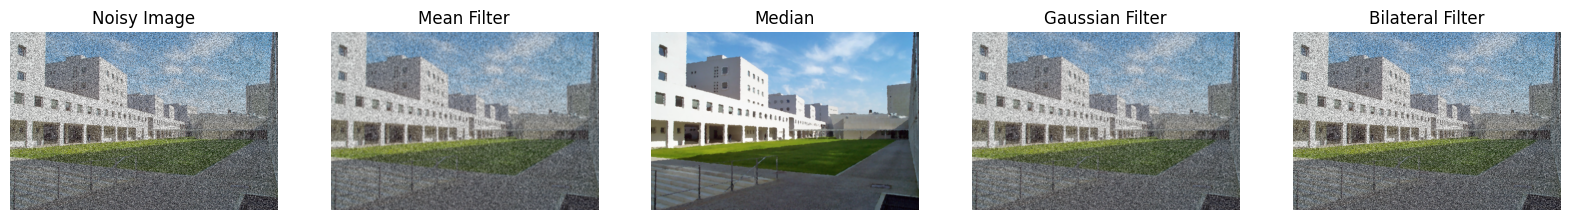

In [21]:
def add_salt_and_pepper(image, prob):
    '''
    Add salt and pepper noise to image
    prob: Probability of the noise
    '''
    output = image.copy()
    if len(image.shape) == 2:
        black = 0
        white = 255            
    else:
        colorspace = image.shape[2]
        if colorspace == 3:  # RGB
            black = np.array([0, 0, 0], dtype='uint8')
            white = np.array([255, 255, 255], dtype='uint8')
        else:  # RGBA
            black = np.array([0, 0, 0, 255], dtype='uint8')
            white = np.array([255, 255, 255, 255], dtype='uint8')
    probs = np.random.random(output.shape[:2])
    output[probs < (prob / 2)] = black
    output[probs > 1 - (prob / 2)] = white
    return output

img = cv2.imread(os.path.join(dataDir, 'FEUP_01.jpg'))

noisy_image = add_salt_and_pepper(img, 0.4)

img_mean_filter = cv2.blur(noisy_image, ksize=(7, 7))

img_median_filter = cv2.medianBlur(noisy_image, ksize=7)

img_gaussian_filter = cv2.GaussianBlur(noisy_image, ksize=(7, 7), sigmaX=0, sigmaY=0)

img_bilateral_filter = cv2.bilateralFilter(noisy_image, d=7, sigmaColor=75, sigmaSpace=75)

f, axarr = plt.subplots(1, 5, figsize=(20, 5))

axarr[0].imshow(cv2.cvtColor(noisy_image, cv2.COLOR_BGR2RGB))
axarr[0].set_title("Noisy Image")

axarr[1].imshow(cv2.cvtColor(img_mean_filter, cv2.COLOR_BGR2RGB))
axarr[1].set_title("Mean Filter")

axarr[2].imshow(cv2.cvtColor(img_median_filter, cv2.COLOR_BGR2RGB))
axarr[2].set_title("Median")

axarr[3].imshow(cv2.cvtColor(img_gaussian_filter, cv2.COLOR_BGR2RGB))
axarr[3].set_title("Gaussian Filter")

axarr[4].imshow(cv2.cvtColor(img_bilateral_filter, cv2.COLOR_BGR2RGB))
axarr[4].set_title("Bilateral Filter")

for ax in axarr: ax.axis("off")
plt.show()

(Why did the bilateral filter work well previously, but not now?)

Exercise 1.3: Apply your own 3x3 mean filter using [ndimage.convolve()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.convolve.html). Look at the lecture slides for the filter definition.

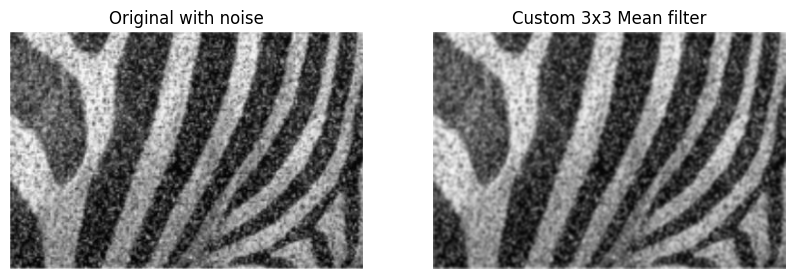

In [11]:
img = cv2.imread(os.path.join(dataDir, 'zebra_01_noisy.jpg'), cv2.IMREAD_GRAYSCALE)

kernel_mean = np.ones((3, 3)) / 9

img_custom_mean = ndimage.convolve(img, kernel_mean)

f, axarr = plt.subplots(1, 2, figsize=(10, 5))

axarr[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axarr[0].set_title("Original with noise")
axarr[0].axis("off")

axarr[1].imshow(img_custom_mean, cmap="gray", vmin=0, vmax=255)
axarr[1].set_title("Custom 3x3 Mean filter")
axarr[1].axis("off")

plt.show()

Exercise 1.4: Apply your own 3x3 Gaussian filter using [ndimage.convolve()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.convolve.html).

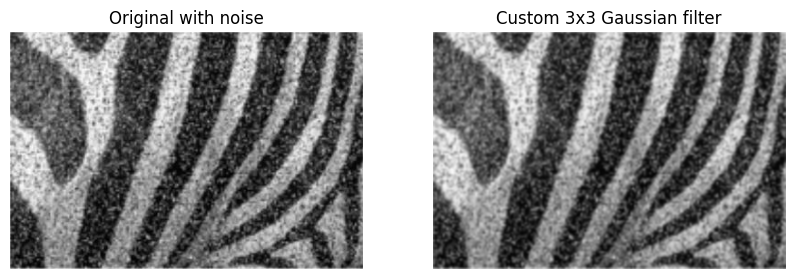

In [12]:
img = cv2.imread(os.path.join(dataDir, 'zebra_01_noisy.jpg'), cv2.IMREAD_GRAYSCALE)

kernel_gaussian = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32) / 16.0

img_custom_gaussian = ndimage.convolve(img, kernel_gaussian)

f, axarr = plt.subplots(1, 2, figsize=(10, 5))

axarr[0].imshow(img, cmap="gray", vmin=0, vmax=255)
axarr[0].set_title("Original with noise")
axarr[0].axis("off")

axarr[1].imshow(img_custom_gaussian, cmap="gray", vmin=0, vmax=255)
axarr[1].set_title("Custom 3x3 Gaussian filter")
axarr[1].axis("off")

plt.show()

Exercise 1.5: Apply two 3x3 Sobel filters (one in the X-direction, the other in the Y-direction) using [ndimage.convolve()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.convolve.html). Look at the lecture slides for the filter definition.

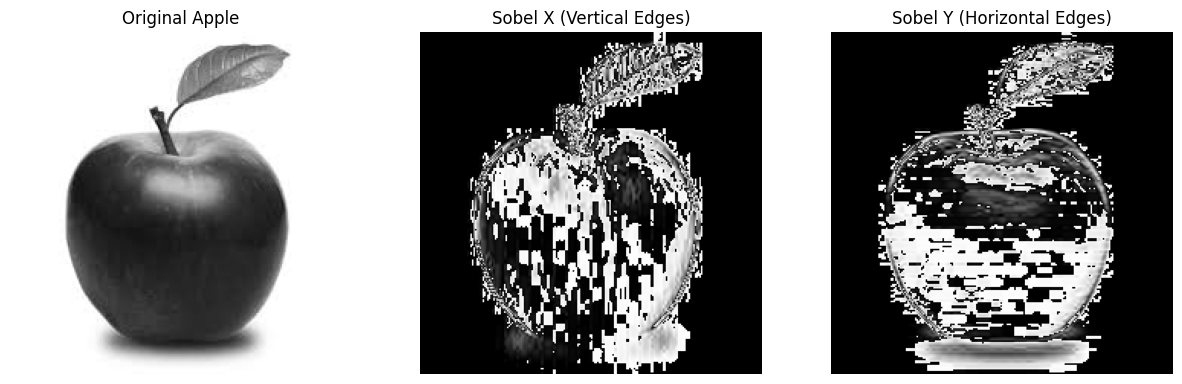

In [23]:
img = cv2.imread(os.path.join(dataDir, 'apple.jpg'), cv2.IMREAD_GRAYSCALE)

# Deteta linhas verticais (se de um lado tiver uma cor e do outro, outra, o resultado da matriz será != 0, logo existe uma aresta)
sobel_x_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# Deteta linhas horizontais
sobel_y_kernel = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

img_sobel_x = ndimage.convolve(img, sobel_x_kernel)
img_sobel_y = ndimage.convolve(img, sobel_y_kernel)

# 'abs' por causa de potenciais valores negativos
img_sobel_x_vis = np.abs(img_sobel_x)
img_sobel_y_vis = np.abs(img_sobel_y)

f, axarr = plt.subplots(1, 3, figsize=(15, 5))

axarr[0].imshow(img, cmap="gray")
axarr[0].set_title("Original Apple")
axarr[0].axis("off")

axarr[1].imshow(img_sobel_x_vis, cmap="gray")
axarr[1].set_title("Sobel X (Vertical Edges)")
axarr[1].axis("off")

axarr[2].imshow(img_sobel_y_vis, cmap="gray")
axarr[2].set_title("Sobel Y (Horizontal Edges)")
axarr[2].axis("off")

plt.show()

Exercise 1.6: Apply your own 3x3 Gaussian filter using [ndimage.convolve()](https://docs.scipy.org/doc/scipy/reference/generated/scipy.ndimage.convolve.html), but now to a colored image.

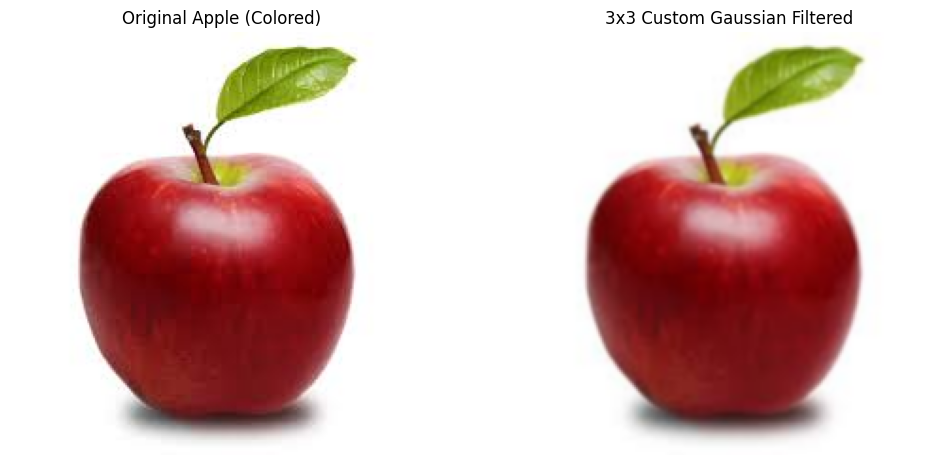

In [33]:
img = cv2.imread(os.path.join(dataDir, 'apple.jpg'))

# Desta vez temos de separar a imagem por canais uma vez que a matriz do kernel é 2D, e uma imagem colorida é 3D
# Assim conseguimos trabalhar com 3 imagens 2D (para cada cor primária) e depois juntar tudo novamente com o filtro já aplicado

kernel_gaussian = np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
], dtype=np.float32) / 16.0

b, g, r = cv2.split(img)

b_filtered = ndimage.convolve(b, kernel_gaussian)
g_filtered = ndimage.convolve(g, kernel_gaussian)
r_filtered = ndimage.convolve(r, kernel_gaussian)

img_filtered = cv2.merge([b_filtered, g_filtered, r_filtered])

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_filtered_rgb = cv2.cvtColor(img_filtered, cv2.COLOR_BGR2RGB)

f, axarr = plt.subplots(1, 2, figsize=(12, 6))

axarr[0].imshow(img_rgb)
axarr[0].set_title("Original Apple (Colored)")
axarr[0].axis("off")

axarr[1].imshow(img_filtered_rgb)
axarr[1].set_title("3x3 Custom Gaussian Filtered")
axarr[1].axis("off")

plt.show()

### 2. Histogram Equalization

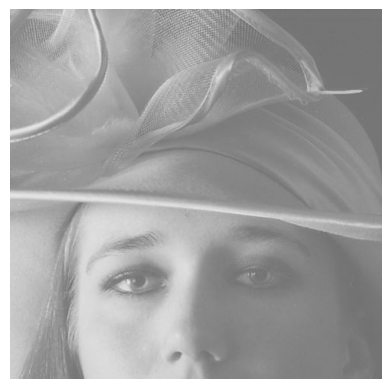

In [59]:
# Load low contrast image
img = cv2.imread(os.path.join(dataDir, 'face_lowContrast_01.jpg'), cv2.IMREAD_GRAYSCALE) # Change this, according to your image's path

plt.imshow(img, cmap="gray", vmin=0, vmax=255)
_ = plt.axis("off")

[Histograms Equalization](https://docs.opencv.org/master/d6/dc7/group__imgproc__hist.html#ga7e54091f0c937d49bf84152a16f76d6e)

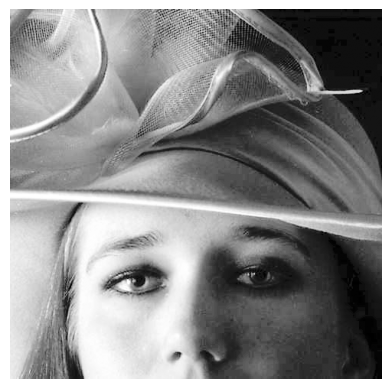

In [60]:
# Increasing contrast with Histograms Equalization
img_with_he = cv2.equalizeHist(img)

plt.imshow(img_with_he, cmap="gray", vmin=0, vmax=255)
_ = plt.axis("off")

[Contrast Limited Adaptive Histogram Equalization](https://docs.opencv.org/master/d6/dc7/group__imgproc__hist.html#gad689d2607b7b3889453804f414ab1018)

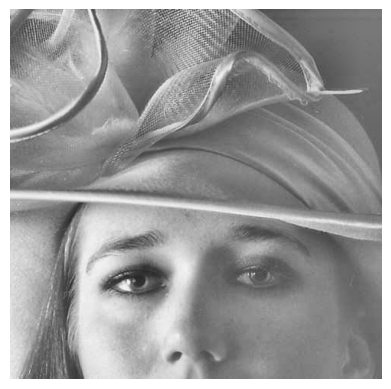

In [61]:
# Increasing contrast with CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_with_CLAHE = clahe.apply(img)

plt.imshow(img_with_CLAHE, cmap="gray", vmin=0, vmax=255)
_ = plt.axis("off")

Exercise 2.1: Apply Histogram Equalization to a colored image

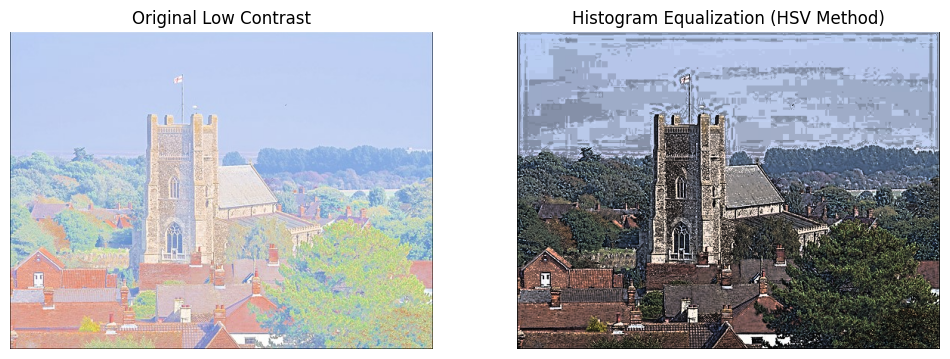

In [78]:
img = cv2.imread(os.path.join(dataDir, 'lowContrast_05.jpg'))

# Converter para HSV para separar e equalizar apenas o brilho (V) sem distorcer as cores originais (H, S)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

(H, S, V) = cv2.split(img_hsv)

EQUALIZED_V = cv2.equalizeHist(V)

img_equalized = cv2.merge([H, S, EQUALIZED_V])

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_equalized_rgb = cv2.cvtColor(img_equalized, cv2.COLOR_HSV2RGB)

f, axarr = plt.subplots(1, 2, figsize=(12, 6))

axarr[0].imshow(img_rgb)
axarr[0].set_title("Original Low Contrast")
axarr[0].axis("off")

axarr[1].imshow(img_equalized_rgb)
axarr[1].set_title("Histogram Equalization (HSV Method)")
axarr[1].axis("off")

plt.show()

Exercise 2.2: Apply CLAHE to a colored image

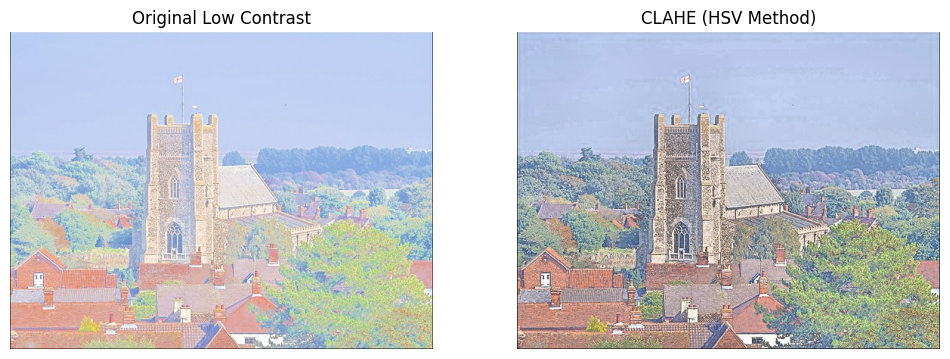

In [83]:
img = cv2.imread(os.path.join(dataDir, 'lowContrast_05.jpg'))

img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

(H, S, V) = cv2.split(img_hsv)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
CLAHE_V = clahe.apply(V)

img_clahe = cv2.merge([H, S, CLAHE_V])

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_clahe_rgb = cv2.cvtColor(img_clahe, cv2.COLOR_HSV2RGB)

f, axarr = plt.subplots(1, 2, figsize=(12, 6))

axarr[0].imshow(img_rgb)
axarr[0].set_title("Original Low Contrast")
axarr[0].axis("off")

axarr[1].imshow(img_clahe_rgb)
axarr[1].set_title("CLAHE (HSV Method)")
axarr[1].axis("off")

plt.show()